# Two-Triangle Benchmark Report

This notebook reads the latest run under `benchmarks/two_triangle/results/runs/`
and produces six standard comparison outputs:

1. Per-case winner table
2. Variants × cases speed heatmap (vs baseline)
3. Variants × cases accuracy heatmap (vs baseline)
4. Pareto scatter: speed vs final folds
5. Trajectory overlays for real cases (fold count vs time)
6. Solution-quality table (l2_disp, smoothness vs baseline)

To refresh: re-run all cells.

In [1]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure repo root is on sys.path so benchmarks package is importable.
# nbconvert runs with cwd = directory of the notebook (benchmarks/two_triangle/).
_NOTEBOOK_DIR = Path(".").resolve()
_REPO_ROOT = _NOTEBOOK_DIR.parents[1]  # two_triangle -> benchmarks -> repo root
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from benchmarks.two_triangle.result import SolverResult  # noqa: E402

RUNS_DIR = _NOTEBOOK_DIR / "results" / "runs"
latest = sorted(RUNS_DIR.iterdir())[-1]
manifest = json.loads((latest / "manifest.json").read_text())
print(f"Run: {latest.name}  |  cells: {manifest['n_cells']}  |  git: {manifest['git_sha'][:8]}")
cells = pd.DataFrame(manifest["cells"])
ok = cells[cells["status"] == "ok"].copy()
print(f"  ok: {len(ok)}  |  errors: {(cells['status'] == 'error').sum()}  |  skipped: {(cells['status'] == 'skipped').sum()}")
ok.head()

Run: 20260509T012818Z  |  cells: 28  |  git: 10bf9393
  ok: 28  |  errors: 0  |  skipped: 0


,variant,case,case_meta,started_at,status,wall_s,rss_before_mb,rss_after_mb,rss_delta_mb,converged,timed_out,final_folds_jdet,final_folds_tri,n_traj_rows,parquet
0,active_set,synth2d_single_cell_flip,"{'category': 'synthetic_2d', 'dim': 2}",20260509T012818Z,ok,0.041613,145.109375,146.917969,1.808594,True,False,0,0,2,active_set\synth2d_single_cell_flip.parquet
1,active_set,synth2d_horizontal_bowtie,"{'category': 'synthetic_2d', 'dim': 2}",20260509T012818Z,ok,0.280216,150.324219,151.468750,1.144531,False,False,10,11,2,active_set\synth2d_horizontal_bowtie.parquet
2,active_set,synth2d_diagonal_bowtie,"{'category': 'synthetic_2d', 'dim': 2}",20260509T012818Z,ok,0.339982,151.476562,153.132812,1.656250,False,False,7,19,2,active_set\synth2d_diagonal_bowtie.parquet
3,active_set,synth2d_layered_bowtie_stack,"{'category': 'synthetic_2d', 'dim': 2}",20260509T012819Z,ok,0.770720,153.152344,153.160156,0.007812,False,False,6,39,4,active_set\synth2d_layered_bowtie_stack.parquet
4,baseline_serial,synth2d_single_cell_flip,"{'category': 'synthetic_2d', 'dim': 2}",20260509T012820Z,ok,0.007725,153.175781,153.210938,0.035156,True,False,0,0,1,baseline_serial\synth2d_single_cell_flip.parquet


In [2]:
# 1. Per-case winner: minimize fold_count_tri × wall_s
ok["score"] = (ok["final_folds_tri"] + 1) * ok["wall_s"]
winners = (ok.sort_values("score")
             .groupby("case", as_index=False)
             .first()[["case", "variant", "final_folds_tri", "wall_s", "score"]])
winners

,case,variant,final_folds_tri,wall_s,score
0,synth2d_diagonal_bowtie,svf_warmstart,0,0.018358,0.018358
1,synth2d_horizontal_bowtie,svf_warmstart,0,0.002367,0.002367
2,synth2d_layered_bowtie_stack,svf_warmstart,0,0.003559,0.003559
3,synth2d_single_cell_flip,svf_warmstart,0,0.005193,0.005193


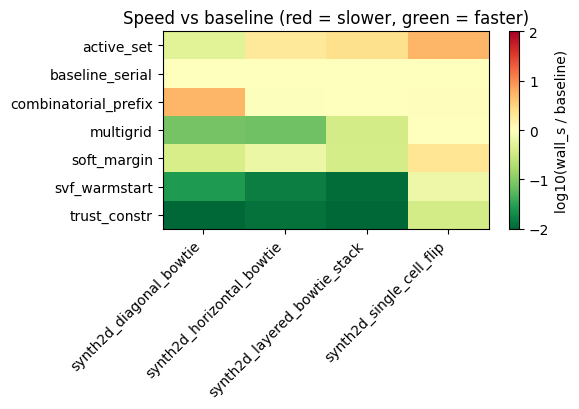

In [3]:
# 2. Speed heatmap: log10(wall_s / baseline_wall_s)
pivot_time = ok.pivot(index="variant", columns="case", values="wall_s")
baseline = pivot_time.loc["baseline_serial"]
log_ratio = np.log10(pivot_time / baseline)
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(pivot_time.columns)), 0.6 * len(pivot_time)))
im = ax.imshow(log_ratio, cmap="RdYlGn_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(pivot_time.columns))); ax.set_xticklabels(pivot_time.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_time.index))); ax.set_yticklabels(pivot_time.index)
plt.colorbar(im, ax=ax, label="log10(wall_s / baseline)")
ax.set_title("Speed vs baseline (red = slower, green = faster)")
plt.tight_layout(); plt.show()

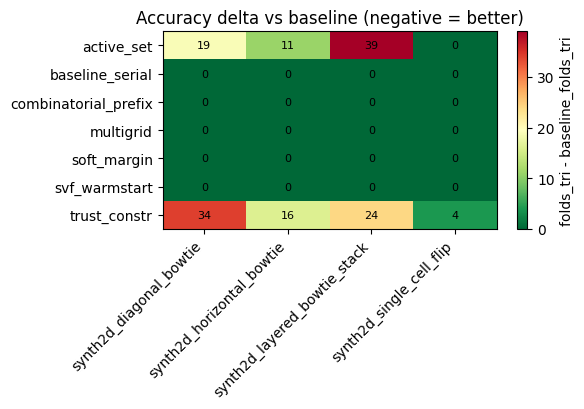

In [4]:
# 3. Accuracy heatmap: final_folds_tri minus baseline
pivot_folds = ok.pivot(index="variant", columns="case", values="final_folds_tri")
delta = pivot_folds.sub(pivot_folds.loc["baseline_serial"], axis="columns")
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(pivot_folds.columns)), 0.6 * len(pivot_folds)))
im = ax.imshow(delta, cmap="RdYlGn_r", aspect="auto")
ax.set_xticks(range(len(pivot_folds.columns))); ax.set_xticklabels(pivot_folds.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_folds.index))); ax.set_yticklabels(pivot_folds.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        ax.text(j, i, int(delta.iloc[i, j]), ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, label="folds_tri - baseline_folds_tri")
ax.set_title("Accuracy delta vs baseline (negative = better)")
plt.tight_layout(); plt.show()

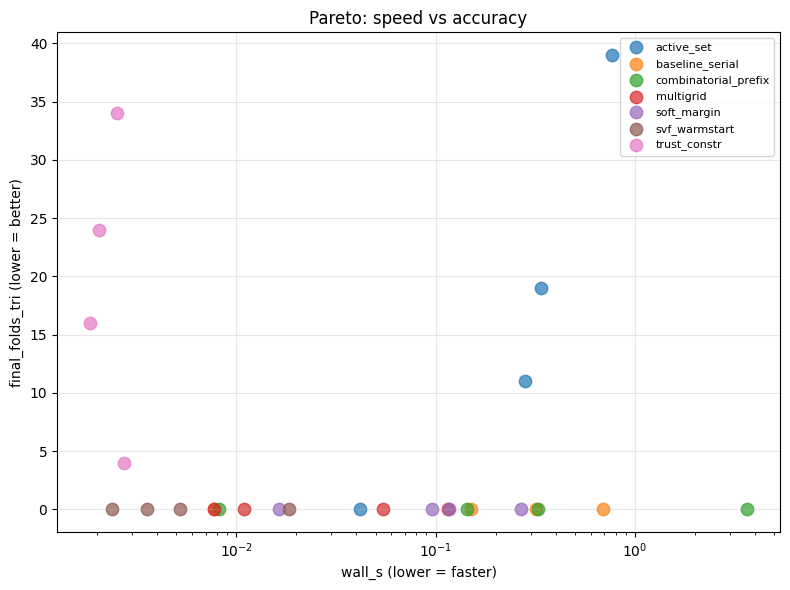

In [5]:
# 4. Pareto scatter: speed vs folds
fig, ax = plt.subplots(figsize=(8, 6))
for v, group in ok.groupby("variant"):
    ax.scatter(group["wall_s"], group["final_folds_tri"], label=v, s=80, alpha=0.7)
ax.set_xlabel("wall_s (lower = faster)"); ax.set_ylabel("final_folds_tri (lower = better)")
ax.set_xscale("log")
ax.legend(loc="best", fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Pareto: speed vs accuracy")
plt.tight_layout(); plt.show()

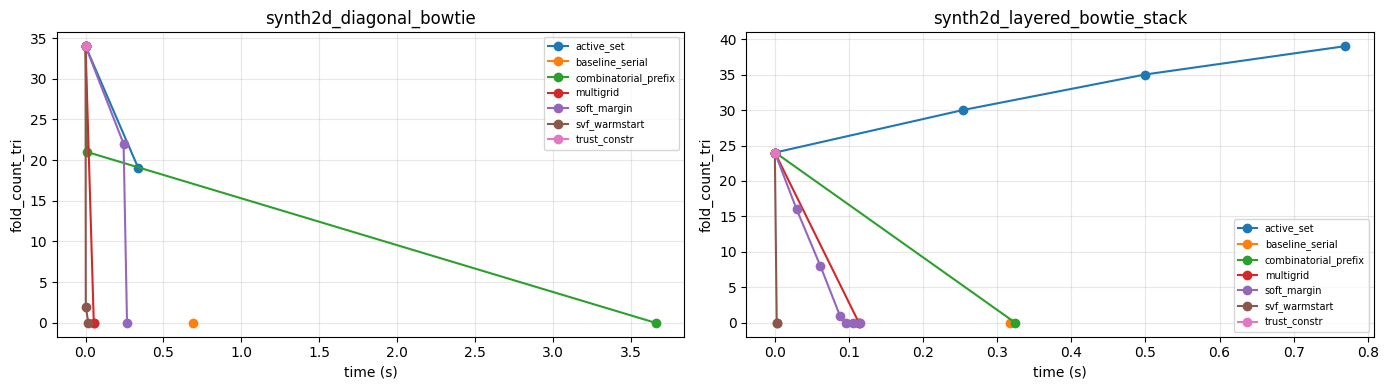

In [6]:
# 5. Trajectory overlays for the 2 longest-running cases (proxy for "real" or hard)
hardest = ok.groupby("case")["wall_s"].max().nlargest(2).index.tolist()
fig, axes = plt.subplots(1, len(hardest), figsize=(7 * len(hardest), 4), squeeze=False)
for ax, case in zip(axes[0], hardest):
    for _, row in ok[ok["case"] == case].iterrows():
        parquet = latest / row["parquet"]
        if not parquet.exists():
            continue
        traj = pd.read_parquet(parquet)
        ax.plot(traj["time_s"], traj["fold_count_tri"], marker="o", label=row["variant"])
    ax.set_title(case); ax.set_xlabel("time (s)"); ax.set_ylabel("fold_count_tri")
    ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [7]:
# 6. Solution quality: l2_disp + smoothness deltas
def _final_metric(parquet, col):
    return float(pd.read_parquet(latest / parquet).iloc[-1][col])

ok["final_l2_disp"] = ok["parquet"].apply(lambda p: _final_metric(p, "l2_disp"))
ok["final_smoothness"] = ok["parquet"].apply(lambda p: _final_metric(p, "smoothness"))
quality = ok[["case", "variant", "final_l2_disp", "final_smoothness"]].pivot(
    index="variant", columns="case")
quality

final_l2_disp                            \
case                 synth2d_diagonal_bowtie synth2d_horizontal_bowtie   
variant                                                                  
active_set                          2.585414                  2.181263   
baseline_serial                     4.429705                  2.995268   
combinatorial_prefix                8.536284                  2.995268   
multigrid                           5.540462                  4.006032   
soft_margin                         0.159887                  0.109531   
svf_warmstart                       5.387251                  3.380389   
trust_constr                        0.000000                  0.000000   

                                                                            \
case                 synth2d_layered_bowtie_stack synth2d_single_cell_flip   
variant                                                                      
active_set                               3.539951                 1.442403   
baseline_serial                          5.157465                 1.442403   
combinatorial_prefix                     5.157465                 1.442403   
multigrid                                9.359498                 1.442403   
soft_margin                              0.109892                 0.028282   
svf_warmstart                            5.634322                 1.530930   
trust_constr                             0.000000                 0.000000   

                            final_smoothness                            \
case                 synth2d_diagonal_bowtie synth2d_horizontal_bowtie   
variant                                                                  
active_set                          6.361243                  5.368592   
baseline_serial                     3.687863                  3.087346   
combinatorial_prefix                7.183825                  3.087346   
multigrid                           2.679149                  2.206055   
soft_margin                         3.686970                  3.086665   
svf_warmstart                       3.946110                  3.341610   
trust_constr                        6.479212                  5.197195   

                                                                            
case                 synth2d_layered_bowtie_stack synth2d_single_cell_flip  
variant                                                                     
active_set                              10.483589                 1.966713  
baseline_serial                          6.716318                 1.966713  
combinatorial_prefix                     6.716318                 1.966713  
multigrid                                5.212022                 1.966713  
soft_margin                              6.714818                 1.966334  
svf_warmstart                            6.625360                 1.400095  
trust_constr                            10.391017                 4.015402